In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Outlier detection

In [50]:
data={
    "Months":["jan",'feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec'],
    "Sales":[23345,65754,878785,23454,67466,57867,78998,32443,56745,967867,42355,67856]
}

In [51]:
df=pd.DataFrame(data)

In [52]:
df

,Months,Sales
0,jan,23345
1,feb,65754
2,mar,878785
3,apr,23454
4,may,67466
5,jun,57867
6,jul,78998
7,aug,32443
8,sep,56745
9,oct,967867


In [53]:
df.Sales.mean()

np.float64(196911.25)

<function matplotlib.pyplot.show(close=None, block=None)>

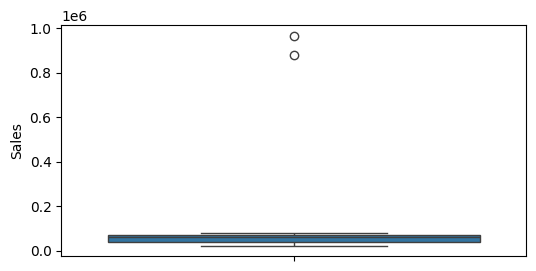

In [54]:
plt.figure(figsize=(6,3))
sns.boxplot(df["Sales"])
plt.show

In [55]:
df.describe()

,Sales
count,12.000000
mean,196911.250000
std,340316.917798
min,23345.000000
25%,39877.000000
50%,61810.500000
75%,70641.500000
max,967867.000000


# IQR(inter quantile range)
# IQR=Q3-Q1
# Q3=75th percentile value of asc order
# Q1=25th percentile value of asc order

In [24]:
Q3=df['Sales'].quantile(0.75)
Q1=df['Sales'].quantile(0.25)
Q3-Q1

np.float64(30764.5)

In [29]:
min_value=Q1-1.5*30764.5
max_value=Q3+1.5*30764.5
min_value,max_value

(np.float64(-6269.75), np.float64(116788.25))

In [56]:
df=df[df['Sales']> max_value]

In [57]:
df

,Months,Sales
2,mar,878785
9,oct,967867


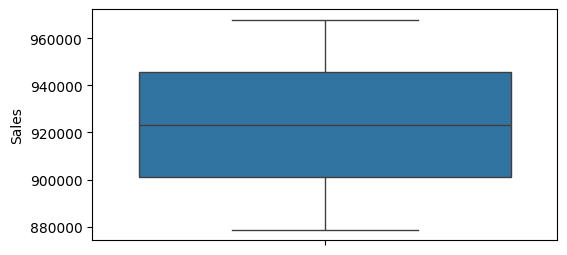

In [59]:
plt.figure(figsize=(6,3))
sns.boxplot(df['Sales'])
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_12984\1505624234.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Sales'])


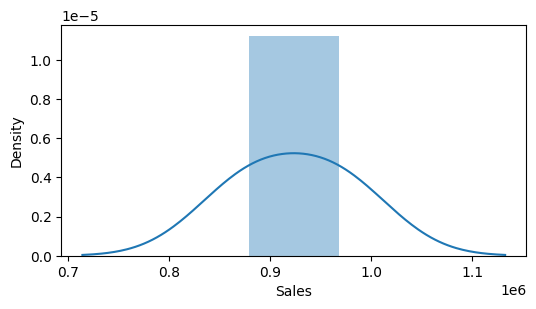

In [60]:
plt.figure(figsize=(6,3))
sns.distplot(df['Sales'])
plt.show()

In [64]:
newdata={
    "Months":["jan",'feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec'],
    "Sales":[23345,65754,878785,23454,67466,57867,78998,32443,56745,967867,42355,67856]
}

In [69]:
df=pd.DataFrame(newdata)

In [72]:
df['z_score']=(df["Sales"]-df["Sales"].mean())/df["Sales"].std()

In [73]:
df

,Months,Sales,z_score
0,jan,23345,-0.510014
1,feb,65754,-0.385397
2,mar,878785,2.003643
3,apr,23454,-0.509693
4,may,67466,-0.380367
5,jun,57867,-0.408573
6,jul,78998,-0.346481
7,aug,32443,-0.483280
8,sep,56745,-0.411870
9,oct,967867,2.265405


In [74]:
df=df[df['z_score']<2];

In [75]:
df

,Months,Sales,z_score
0,jan,23345,-0.510014
1,feb,65754,-0.385397
3,apr,23454,-0.509693
4,may,67466,-0.380367
5,jun,57867,-0.408573
6,jul,78998,-0.346481
7,aug,32443,-0.483280
8,sep,56745,-0.411870
10,nov,42355,-0.454154
11,dec,67856,-0.379221


In [76]:
df=df.drop(columns="z_score")

In [77]:
df

,Months,Sales
0,jan,23345
1,feb,65754
3,apr,23454
4,may,67466
5,jun,57867
6,jul,78998
7,aug,32443
8,sep,56745
10,nov,42355
11,dec,67856


In [79]:
df=sns.load_dataset('titanic')

In [80]:
df.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [91]:
df=df.drop(columns=[''who','adult_male','class','embark_town',])

KeyError: "['alive'] not found in axis"

In [95]:
df = df.drop(columns=['alive', 'alone'], errors='ignore')


In [96]:
df.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
0,0,3,male,22.0,1,0,7.2500,S,NaN
1,1,1,female,38.0,1,0,71.2833,C,C
2,1,3,female,26.0,0,0,7.9250,S,NaN


In [97]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
deck        688
dtype: int64

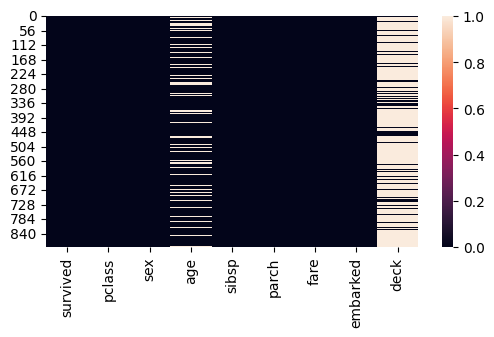

In [98]:
plt.figure(figsize=(6,3))
sns.heatmap(df.isnull())
plt.show()

In [99]:
df=df.drop(columns="deck")

In [101]:
df=df.ffill()

In [102]:
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

In [103]:
for col in df.select_dtypes(include=float).columns:
    print(col)

age
fare


In [105]:
for col in df.select_dtypes(include=float).columns:
    df[col]=(df[col]-df[col].min())/(df[col].max()-df[col].min())

In [106]:
df.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,0.271174,1,0,0.014151,S
1,1,1,female,0.472229,1,0,0.139136,C
2,1,3,female,0.321438,0,0,0.015469,S


In [110]:
for col in df.select_dtypes(include='str').columns:
    df[col]=df[col].map(lambda val:list(df[col].unique()).index(val))


In [111]:
df.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,0,0.271174,1,0,0.014151,0
1,1,1,1,0.472229,1,0,0.139136,1
2,1,3,1,0.321438,0,0,0.015469,0


In [112]:
# Data split into input and output
X=df.drop(columns=["survived"])
y=df['survived']

In [113]:
# Train test split

In [119]:
from sklearn.model_selection import train_test_split

In [120]:
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.20, random_state=42)

In [114]:
from sklearn.linear_model import LogisticRegression

In [115]:
model=LogisticRegression()

In [121]:
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [122]:
y_pred=model.predict(X_test)

In [123]:
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1])

In [125]:
from sklearn.metrics import accuracy_score

In [126]:
accuracy_score(y_test,y_pred)*100

79.3296089385475